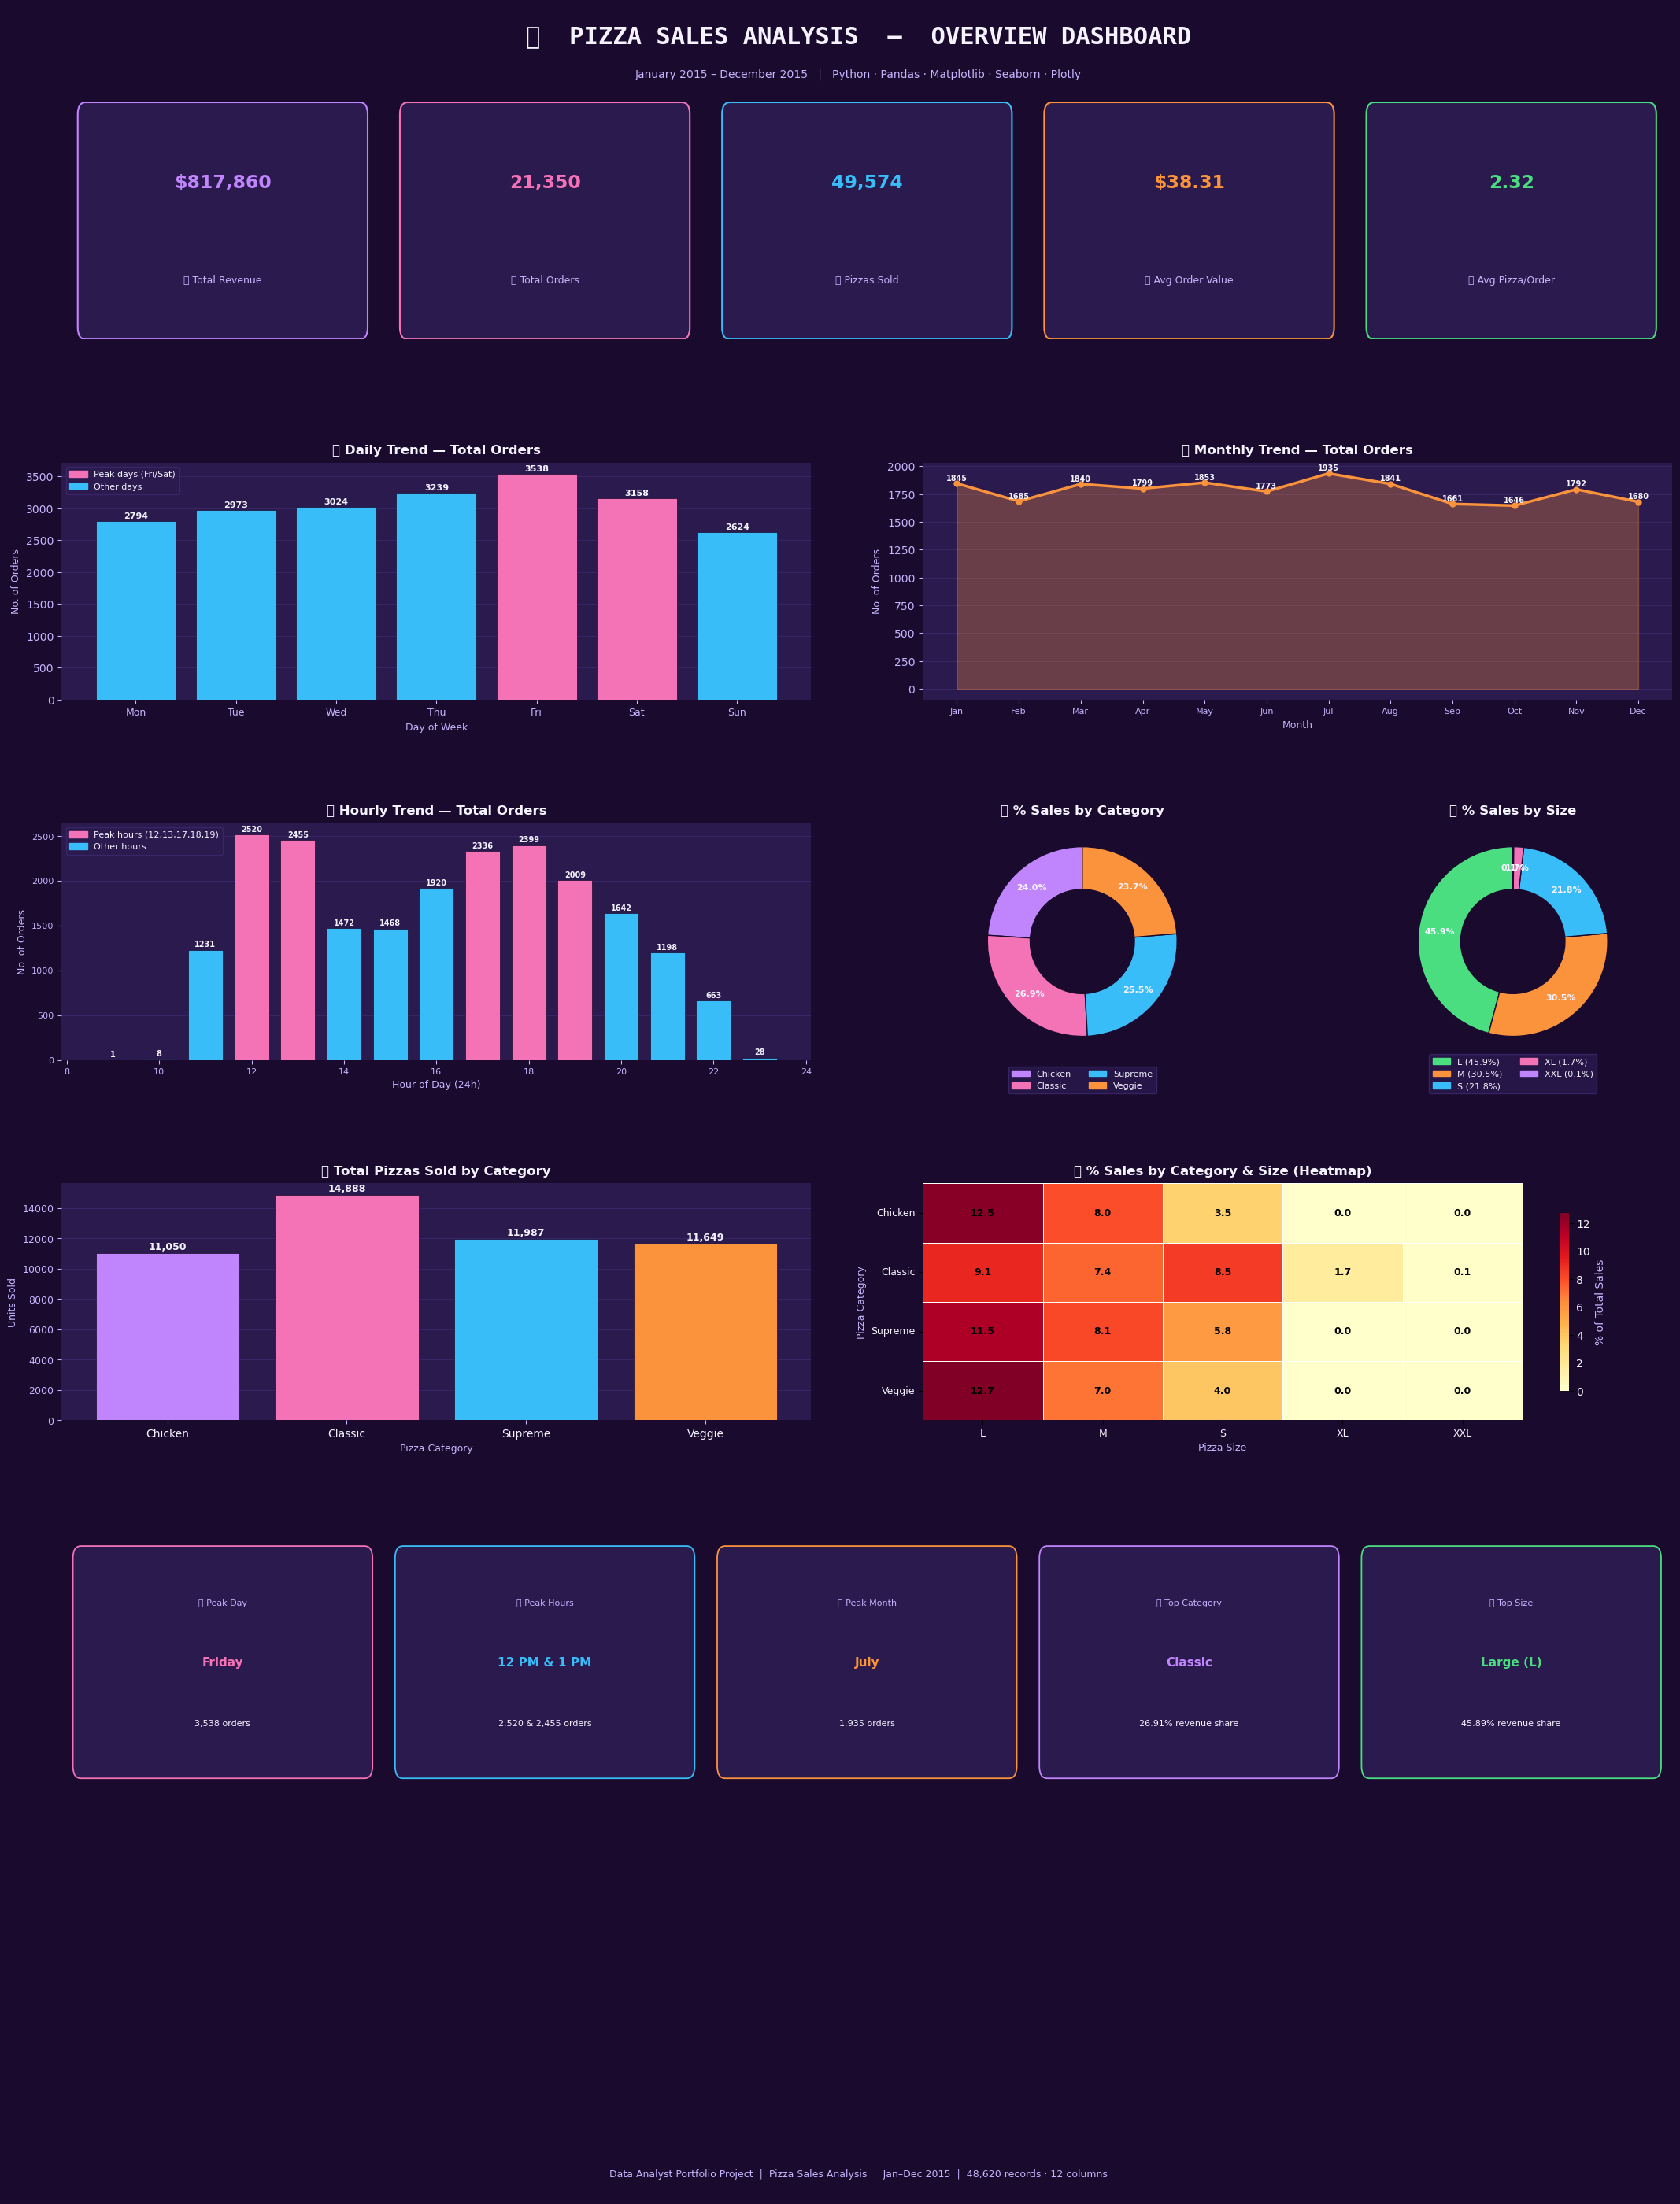

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──
df = pd.read_csv("D:/Downloads/pizza_sales.csv")

# ── Feature Engineering ──
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')
df['order_hour'] = df['order_time'].dt.hour

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
month_order   = ["January","February","March","April","May","June",
                 "July","August","September","October","November","December"]

df['day_name']   = pd.Categorical(df['order_date'].dt.day_name(),   categories=weekday_order, ordered=True)
df['month_name'] = pd.Categorical(df['order_date'].dt.month_name(), categories=month_order,   ordered=True)

# ── KPIs ──
total_revenue      = df['total_price'].sum()           # $817,860.05
total_pizzas_sold  = df['quantity'].sum()               # 49,574
total_orders       = df['order_id'].nunique()           # 21,350
avg_order_value    = total_revenue / total_orders       # $38.31
avg_pizzas_per_ord = total_pizzas_sold / total_orders   # 2.32

# ── Aggregations ──
orders_by_day   = df.groupby('day_name',   observed=False)['order_id'].nunique()
orders_by_month = df.groupby('month_name', observed=False)['order_id'].nunique()
orders_by_hour  = df.groupby('order_hour', observed=False)['order_id'].nunique()
category_sales  = df.groupby('pizza_category')['total_price'].sum()
category_pct    = category_sales / category_sales.sum() * 100
size_sales      = df.groupby('pizza_size')['total_price'].sum()
size_pct        = size_sales / size_sales.sum() * 100
pizzas_by_cat   = df.groupby('pizza_category')['quantity'].sum()
sales_pivot     = df.pivot_table(index='pizza_category', columns='pizza_size',
                      values='total_price', aggfunc='sum', fill_value=0)
sales_pct_hm    = sales_pivot / sales_pivot.sum().sum() * 100

# ── Colour Palette ──
BG      = "#1a0a2e"
CARD_BG = "#2a1a4e"
ACCENT1 = "#c084fc"   # purple
ACCENT2 = "#f472b6"   # pink
ACCENT3 = "#38bdf8"   # blue
ACCENT4 = "#fb923c"   # orange
ACCENT5 = "#4ade80"   # green
TEXT    = "#f5f3ff"
SUBTEXT = "#c4b5fd"
GRID    = "#3d2a6e"

# ── Figure & GridSpec ──
fig = plt.figure(figsize=(22, 28), facecolor=BG)
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(6, 4, figure=fig,
    top=0.955, bottom=0.030, left=0.040, right=0.970,
    hspace=0.52, wspace=0.35)

# ── Title Bar ──
ax_t = fig.add_axes([0.03, 0.961, 0.94, 0.037])
ax_t.set_facecolor(CARD_BG); ax_t.axis('off')
ax_t.text(0.5, 0.65, "🍕  PIZZA SALES ANALYSIS  —  OVERVIEW DASHBOARD",
    fontsize=22, fontweight='bold', color=TEXT, ha='center', va='center', fontfamily='monospace')
ax_t.text(0.5, 0.18, "January 2015 – December 2015   |   Python · Pandas · Matplotlib · Seaborn · Plotly",
    fontsize=10, color=SUBTEXT, ha='center', va='center')
for sp in ax_t.spines.values(): sp.set_edgecolor(ACCENT1); sp.set_linewidth(1.5)

# ── KPI Strip (row 0) ──
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor(BG); ax_kpi.axis('off')
ax_kpi.set_xlim(0, 10); ax_kpi.set_ylim(0, 1)
kpis = [
    ("💰 Total Revenue",   f"${total_revenue:,.0f}",     ACCENT1),
    ("📦 Total Orders",    f"{total_orders:,}",           ACCENT2),
    ("🍕 Pizzas Sold",     f"{total_pizzas_sold:,}",      ACCENT3),
    ("🧾 Avg Order Value", f"${avg_order_value:,.2f}",    ACCENT4),
    ("📊 Avg Pizza/Order", f"{avg_pizzas_per_ord:,.2f}",  ACCENT5),
]
for x, (label, value, color) in zip([1.0, 3.0, 5.0, 7.0, 9.0], kpis):
    ax_kpi.add_patch(mpatches.FancyBboxPatch(
        (x-0.85, 0.05), 1.70, 0.90,
        boxstyle="round,pad=0.05", facecolor=CARD_BG, edgecolor=color, linewidth=1.5))
    ax_kpi.text(x, 0.66, value, fontsize=17, fontweight='bold', color=color, ha='center', va='center')
    ax_kpi.text(x, 0.25, label, fontsize=9,  color=SUBTEXT, ha='center', va='center')

# ── Chart 1: Orders by Day (row 1, cols 0-1) ──
ax1 = fig.add_subplot(gs[1, :2])
ax1.set_facecolor(CARD_BG)
day_colors = [ACCENT2 if d in ['Friday','Saturday'] else ACCENT3 for d in orders_by_day.index]
bars1 = ax1.bar(range(len(orders_by_day)), orders_by_day.values, color=day_colors, edgecolor=BG, linewidth=0.5)
ax1.set_title("📅 Daily Trend — Total Orders", color=TEXT, fontsize=12, fontweight='bold', pad=8)
ax1.set_xlabel("Day of Week", color=SUBTEXT, fontsize=9)
ax1.set_ylabel("No. of Orders", color=SUBTEXT, fontsize=9)
ax1.set_xticks(range(len(orders_by_day)))
ax1.set_xticklabels([d[:3] for d in orders_by_day.index], color=SUBTEXT, fontsize=9)
ax1.tick_params(colors=SUBTEXT)
ax1.spines[['top','right','left','bottom']].set_visible(False)
ax1.yaxis.grid(True, color=GRID, linewidth=0.5); ax1.set_axisbelow(True)
for bar, val in zip(bars1, orders_by_day.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+18,
             str(val), ha='center', va='bottom', fontsize=8, color=TEXT, fontweight='bold')
ax1.legend(handles=[Patch(color=ACCENT2, label='Peak days (Fri/Sat)'),
                    Patch(color=ACCENT3, label='Other days')],
    fontsize=8, labelcolor=TEXT, facecolor=CARD_BG, edgecolor=GRID, loc='upper left')

# ── Chart 2: Monthly Trend (row 1, cols 2-3) ──
ax2 = fig.add_subplot(gs[1, 2:])
ax2.set_facecolor(CARD_BG)
x_m = range(len(orders_by_month))
ax2.fill_between(x_m, orders_by_month.values, color=ACCENT4, alpha=0.30)
ax2.plot(x_m, orders_by_month.values, color=ACCENT4, linewidth=2.5, marker='o', markersize=5)
ax2.set_title("📆 Monthly Trend — Total Orders", color=TEXT, fontsize=12, fontweight='bold', pad=8)
ax2.set_xlabel("Month", color=SUBTEXT, fontsize=9)
ax2.set_ylabel("No. of Orders", color=SUBTEXT, fontsize=9)
ax2.set_xticks(list(x_m))
ax2.set_xticklabels([m[:3] for m in orders_by_month.index], color=SUBTEXT, fontsize=8)
ax2.tick_params(colors=SUBTEXT)
ax2.spines[['top','right','left','bottom']].set_visible(False)
ax2.yaxis.grid(True, color=GRID, linewidth=0.5); ax2.set_axisbelow(True)
for i, val in enumerate(orders_by_month.values):
    ax2.text(i, val+12, str(val), ha='center', va='bottom', fontsize=7, color=TEXT, fontweight='bold')

# ── Chart 3: Hourly Trend (row 2, cols 0-1) ──
ax3 = fig.add_subplot(gs[2, :2])
ax3.set_facecolor(CARD_BG)
hour_colors = [ACCENT2 if h in [12,13,17,18,19] else ACCENT3 for h in orders_by_hour.index]
bars3 = ax3.bar(orders_by_hour.index, orders_by_hour.values,
                color=hour_colors, edgecolor=BG, linewidth=0.5, width=0.75)
ax3.set_title("🕐 Hourly Trend — Total Orders", color=TEXT, fontsize=12, fontweight='bold', pad=8)
ax3.set_xlabel("Hour of Day (24h)", color=SUBTEXT, fontsize=9)
ax3.set_ylabel("No. of Orders",     color=SUBTEXT, fontsize=9)
ax3.tick_params(colors=SUBTEXT, labelsize=8)
ax3.spines[['top','right','left','bottom']].set_visible(False)
ax3.yaxis.grid(True, color=GRID, linewidth=0.5); ax3.set_axisbelow(True)
for bar, val in zip(bars3, orders_by_hour.values):
    if val > 0:
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 str(val), ha='center', va='bottom', fontsize=7, color=TEXT, fontweight='bold')
ax3.legend(handles=[Patch(color=ACCENT2, label='Peak hours (12,13,17,18,19)'),
                    Patch(color=ACCENT3, label='Other hours')],
    fontsize=8, labelcolor=TEXT, facecolor=CARD_BG, edgecolor=GRID, loc='upper left')

# ── Chart 4: % Sales by Category Donut (row 2, col 2) ──
ax4 = fig.add_subplot(gs[2, 2])
ax4.set_facecolor(CARD_BG)
cat_colors = [ACCENT1, ACCENT2, ACCENT3, ACCENT4]
_, _, auto4 = ax4.pie(category_pct.values, labels=None, autopct='%1.1f%%',
    startangle=90, colors=cat_colors, wedgeprops={'edgecolor': BG, 'width': 0.45}, pctdistance=0.78)
for t in auto4: t.set_color(TEXT); t.set_fontsize(8); t.set_fontweight('bold')
ax4.set_title("🍕 % Sales by Category", color=TEXT, fontsize=12, fontweight='bold', pad=8)
ax4.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(cat_colors, category_pct.index)],
    loc='lower center', bbox_to_anchor=(0.5,-0.16), ncol=2, fontsize=8,
    labelcolor=TEXT, facecolor=CARD_BG, edgecolor=GRID)

# ── Chart 5: % Sales by Size Donut (row 2, col 3) ──
ax5 = fig.add_subplot(gs[2, 3])
ax5.set_facecolor(CARD_BG)
size_pct_sorted = size_pct.sort_values(ascending=False)
size_colors = [ACCENT5, ACCENT4, ACCENT3, ACCENT2, ACCENT1]
_, _, auto5 = ax5.pie(size_pct_sorted.values, labels=None, autopct='%1.1f%%',
    startangle=90, colors=size_colors[:len(size_pct_sorted)],
    wedgeprops={'edgecolor': BG, 'width': 0.45}, pctdistance=0.78)
for t in auto5: t.set_color(TEXT); t.set_fontsize(8); t.set_fontweight('bold')
ax5.set_title("📏 % Sales by Size", color=TEXT, fontsize=12, fontweight='bold', pad=8)
ax5.legend(handles=[mpatches.Patch(color=c, label=f"{l} ({v:.1f}%)")
    for c, l, v in zip(size_colors, size_pct_sorted.index, size_pct_sorted.values)],
    loc='lower center', bbox_to_anchor=(0.5,-0.16), ncol=2, fontsize=8,
    labelcolor=TEXT, facecolor=CARD_BG, edgecolor=GRID)

# ── Chart 6: Pizzas Sold by Category (row 3, cols 0-1) ──
ax6 = fig.add_subplot(gs[3, :2])
ax6.set_facecolor(CARD_BG)
bars6 = ax6.bar(pizzas_by_cat.index, pizzas_by_cat.values,
                color=[ACCENT1,ACCENT2,ACCENT3,ACCENT4], edgecolor=BG, linewidth=0.5)
ax6.set_title("📊 Total Pizzas Sold by Category", color=TEXT, fontsize=12, fontweight='bold', pad=8)
ax6.set_xlabel("Pizza Category", color=SUBTEXT, fontsize=9)
ax6.set_ylabel("Units Sold",     color=SUBTEXT, fontsize=9)
ax6.tick_params(colors=SUBTEXT, labelsize=9)
ax6.set_xticklabels(pizzas_by_cat.index, color=TEXT, fontsize=10)
ax6.spines[['top','right','left','bottom']].set_visible(False)
ax6.yaxis.grid(True, color=GRID, linewidth=0.5); ax6.set_axisbelow(True)
for bar, val in zip(bars6, pizzas_by_cat.values):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f"{val:,}", ha='center', va='bottom', fontsize=9, color=TEXT, fontweight='bold')

# ── Chart 7: Heatmap (row 3, cols 2-3) ──
ax7 = fig.add_subplot(gs[3, 2:])
ax7.set_facecolor(CARD_BG)
sns.heatmap(sales_pct_hm, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax7, cbar_kws={'shrink': 0.75, 'label': '% of Total Sales'},
    annot_kws={'size': 9, 'weight': 'bold', 'color': 'black'})
ax7.set_title("🔥 % Sales by Category & Size (Heatmap)", color=TEXT, fontsize=12, fontweight='bold', pad=8)
ax7.set_xlabel("Pizza Size",     color=SUBTEXT, fontsize=9)
ax7.set_ylabel("Pizza Category", color=SUBTEXT, fontsize=9)
ax7.set_xticklabels(ax7.get_xticklabels(), color=TEXT, fontsize=9)
ax7.set_yticklabels(ax7.get_yticklabels(), color=TEXT, fontsize=9, rotation=0)
ax7.collections[0].colorbar.ax.tick_params(labelcolor=TEXT)
ax7.collections[0].colorbar.set_label('% of Total Sales', color=SUBTEXT)

# ── Insight Cards (row 4) ──
ax_ins = fig.add_subplot(gs[4, :])
ax_ins.set_facecolor(BG); ax_ins.axis('off')
ax_ins.set_xlim(0, 10); ax_ins.set_ylim(0, 1)
insights = [
    ("📅 Peak Day",     "Friday",       f"{orders_by_day['Friday']:,} orders",  ACCENT2),
    ("🕐 Peak Hours",   "12 PM & 1 PM", "2,520 & 2,455 orders",                 ACCENT3),
    ("📆 Peak Month",   "July",         f"{orders_by_month['July']:,} orders",  ACCENT4),
    ("🍕 Top Category", "Classic",      "26.91% revenue share",                 ACCENT1),
    ("📏 Top Size",     "Large (L)",    "45.89% revenue share",                 ACCENT5),
]
for i, (label, title, sub, color) in enumerate(insights):
    x = 1.0 + i * 2.0
    ax_ins.add_patch(mpatches.FancyBboxPatch(
        (x-0.88, 0.06), 1.76, 0.88,
        boxstyle="round,pad=0.05", facecolor=CARD_BG, edgecolor=color, linewidth=1.3))
    ax_ins.text(x, 0.75, label, fontsize=8,  color=SUBTEXT, ha='center', va='center')
    ax_ins.text(x, 0.50, title, fontsize=11, color=color,   ha='center', va='center', fontweight='bold')
    ax_ins.text(x, 0.24, sub,   fontsize=8,  color=TEXT,    ha='center', va='center')

# ── Footer ──
ax_foot = fig.add_axes([0.03, 0.005, 0.94, 0.020])
ax_foot.set_facecolor(CARD_BG); ax_foot.axis('off')
ax_foot.text(0.5, 0.5,
    "Data Analyst Portfolio Project  |  Pizza Sales Analysis  |  Jan–Dec 2015  |  48,620 records · 12 columns",
    fontsize=9, color=SUBTEXT, ha='center', va='center')

fig.savefig('Pizza_Dashboard_Page1_Overview.png', dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()